In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt

In [ ]:
data = {
    'Weather':['Sunny','Cloudy','Sunny','Cloudy','Rainy',
               'Rainy','Rainy','Sunny','Cluody','Rainy'],
    'Temperature':['Hot','Hot','Mild','Mild','Mild',
                   'Cool', 'Mild','Hot','Hot','Mild'],
    'Humidity' : ['High','High','Normal','High','High',
                  'Normal','High','High','Normal','High'],
    'Wind' : ['Weak','Weak','Strong','Strong','Strong',
              'Strong','Weak','Strong','Weak','Strong'],
    'Play' : ['No','Yes','Yes','Yes','No',
              'No','Yes','No','Yes','No']
}

df = pd.DataFrame(data)
df

,Weather,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Cloudy,Hot,High,Weak,Yes
2,Sunny,Mild,Normal,Strong,Yes
3,Cloudy,Mild,High,Strong,Yes
4,Rainy,Mild,High,Strong,No
5,Rainy,Cool,Normal,Strong,No
6,Rainy,Mild,High,Weak,Yes
7,Sunny,Hot,High,Strong,No
8,Cluody,Hot,Normal,Weak,Yes
9,Rainy,Mild,High,Strong,No


In [ ]:
encoder = {}

for col in df.columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoder[col] = le

df

,Weather,Temperature,Humidity,Wind,Play
0,3,1,0,1,0
1,0,1,0,1,1
2,3,2,1,0,1
3,0,2,0,0,1
4,2,2,0,0,0
5,2,0,1,0,0
6,2,2,0,1,1
7,3,1,0,0,0
8,1,1,1,1,1
9,2,2,0,0,0


In [ ]:
x = df.drop('Play',axis=1)
y = df['Play']

print('Features')
print(x)

Features
   Weather  Temperature  Humidity  Wind
0        3            1         0     1
1        0            1         0     1
2        3            2         1     0
3        0            2         0     0
4        2            2         0     0
5        2            0         1     0
6        2            2         0     1
7        3            1         0     0
8        1            1         1     1
9        2            2         0     0


In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [ ]:
model.fit(x,y)

print('Model Trained Successfully')

Model Trained Successfully


In [ ]:
importance = model.feature_importances_

for Features, score in zip(x.columns, importance):
  print(Features, ":", score)

Weather : 0.39581560200335825
Temperature : 0.20418439799664173
Humidity : 0.2754887502163469
Wind : 0.12451124978365313


In [ ]:
new_data = pd.DataFrame({

    'Weather' : ['Sunny'],
    'Temperature' : ['Mild'],
    'Humidity' : ['Normal'],
    'Wind' : ['Strong']

})

In [ ]:
for col in new_data.columns:
  new_data[col] = encoder[col].transform(new_data[col])

prediction = model.predict(new_data)
result = encoder['Play'].inverse_transform(prediction)
print("prediction =", result[0])

prediction = Yes


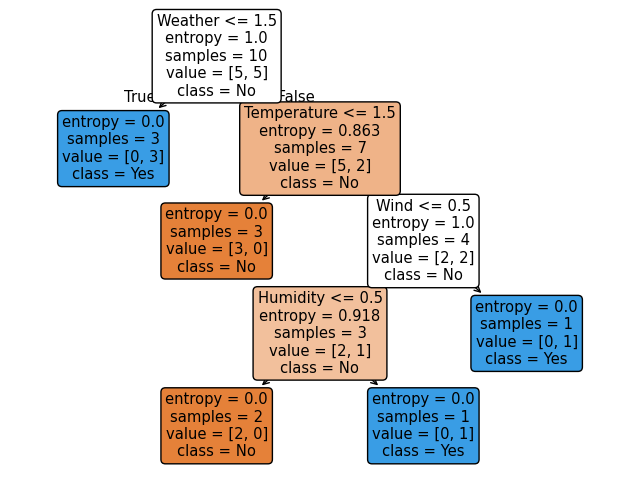

In [ ]:
plt.figure(figsize=(8,6))
plot_tree(
    model,
    filled=True,
    feature_names=x.columns,
    class_names=['No','Yes'],
    rounded=True,
  )
plt.show()

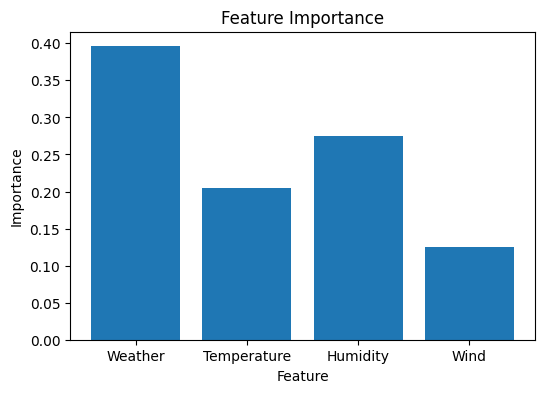

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    x.columns,
    model.feature_importances_
  )

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x)
accuracy = accuracy_score(y, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 100.0 %
